In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('charts', exist_ok=True)
xls = pd.ExcelFile('data/Telco_customer_churn.xlsx')
print(xls.sheet_names)


['Telco_Churn']


In [27]:
df = pd.read_excel('data/Telco_customer_churn.xlsx', sheet_name='Telco_Churn')
df.head()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [28]:
print(df.columns.tolist())


['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [29]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df = df.dropna(subset=['Total Charges'])
print(df.shape)

(7032, 33)


In [30]:
# Overall churn rate
df['Churn Label'].value_counts(normalize=True) * 100

Churn Label
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

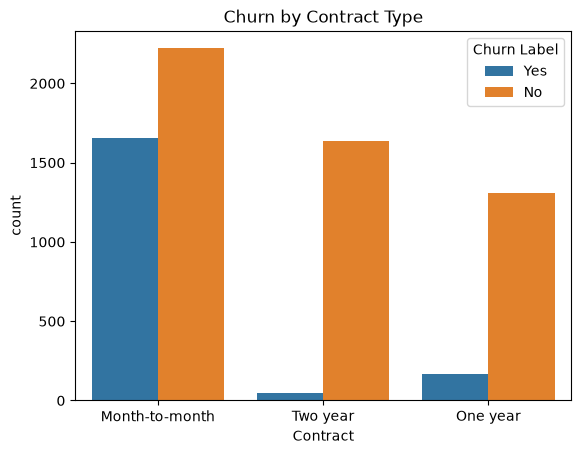

In [31]:
# Churn by contract type
sns.countplot(data=df, x='Contract', hue='Churn Label')
plt.title('Churn by Contract Type')
plt.savefig('charts/churn_by_contract.png', bbox_inches='tight', dpi=150)
plt.show()

Month-to-month customers churn at a much higher rate than 1-year or 2-year contract customers.

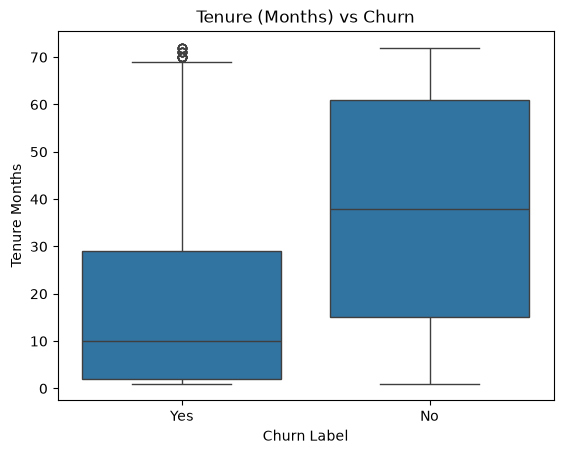

In [41]:
# Tenure vs churn
sns.boxplot(data=df, x='Churn Label', y='Tenure Months')
plt.title('Tenure (Months) vs Churn')
plt.savefig('charts/tenure_vs_churn.png', bbox_inches='tight', dpi=150)
plt.show()

Customers who churned tend to have lower tenure (newer customers), while long-term customers rarely churn.

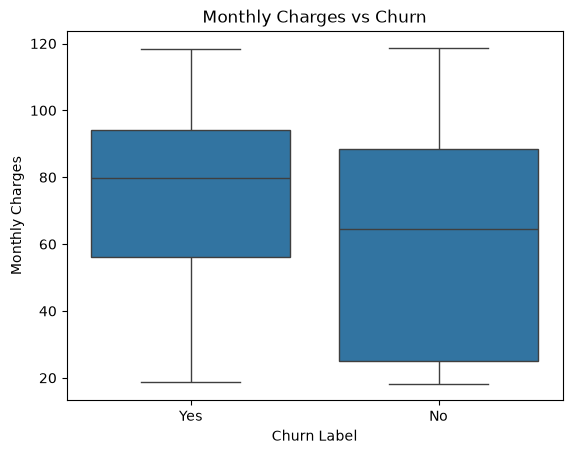

In [50]:
# Monthly charges vs churn
sns.boxplot(data=df, x='Churn Label', y='Monthly Charges')
plt.title('Monthly Charges vs Churn')
plt.savefig('charts/monthly_charges_vs_churn.png', bbox_inches='tight', dpi=150)
plt.show()

Customers with higher monthly charges are more likely to churn.

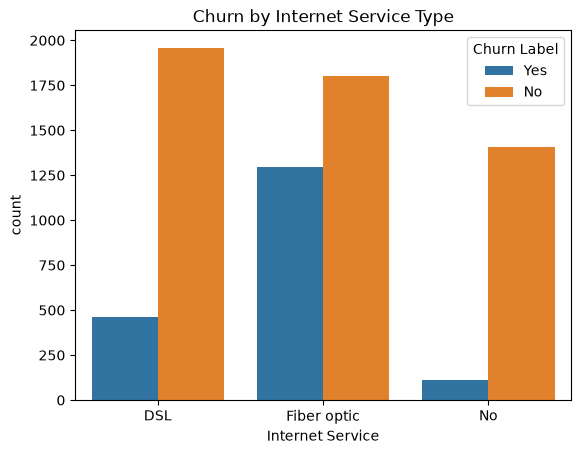

In [58]:
# Internet service vs churn
sns.countplot(data=df, x='Internet Service', hue='Churn Label')
plt.title('Churn by Internet Service Type')
plt.savefig('charts/churn_by_internet_service.png', bbox_inches='tight', dpi=150)
plt.show()

Fiber optic customers churn more than DSL or no-internet customers.

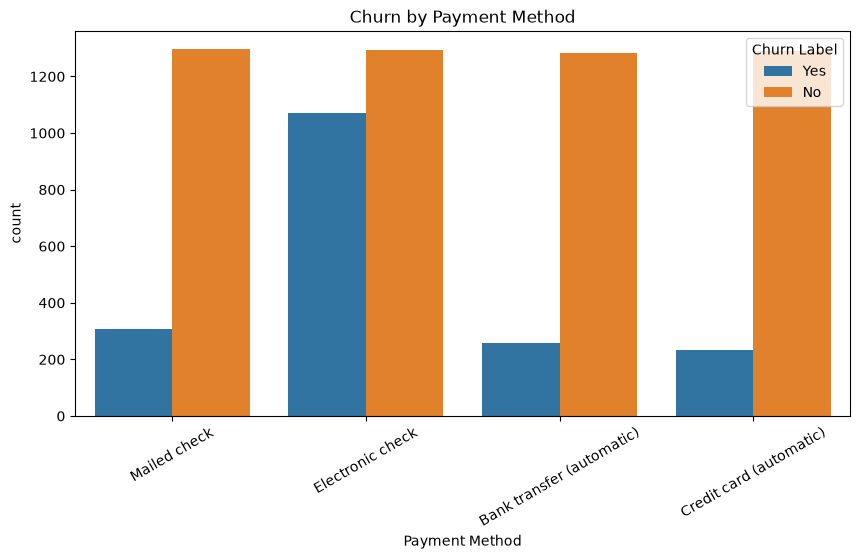

In [65]:
# Payment method vs churn (bonus — this dataset has it, often very revealing)
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Payment Method', hue='Churn Label')
plt.title('Churn by Payment Method')
plt.xticks(rotation=30)
plt.savefig('charts/feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

Customers paying by electronic check churn more than those using automatic payments.

In [66]:
df['Churn_Binary'] = df['Churn Label'].map({'Yes': 1, 'No': 0})

# Drop columns that won't help the model or could "leak" the answer
cols_to_drop = ['CustomerID', 'Count', 'Country', 'State', 'Lat Long', 'Latitude', 'Longitude', 
                 'Zip Code', 'City', 'Churn Label', 'Churn Score', 'Churn Reason', 'CLTV', 'Churn Value']
df_model = df.drop(columns=cols_to_drop)

# Convert remaining categorical columns into numbers
df_model = pd.get_dummies(df_model, drop_first=True)
df_model.head()

,Tenure Months,Monthly Charges,Total Charges,Churn_Binary,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [67]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X = df_model.drop('Churn_Binary', axis=1)
y = df_model['Churn_Binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.8123667377398721
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1012
           1       0.70      0.58      0.63       395

    accuracy                           0.81      1407
   macro avg       0.77      0.74      0.75      1407
weighted avg       0.81      0.81      0.81      1407



In [68]:
importance = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)
print("Top factors that INCREASE churn risk:")
print(importance.head(10))
print("\nTop factors that DECREASE churn risk:")
print(importance.tail(10))

Top factors that INCREASE churn risk:
Internet Service_Fiber optic       0.508850
Paperless Billing_Yes              0.404221
Partner_Yes                        0.308969
Payment Method_Electronic check    0.266323
Multiple Lines_No phone service    0.221974
Multiple Lines_Yes                 0.197830
Senior Citizen_Yes                 0.133236
Streaming Movies_Yes               0.127404
Streaming TV_Yes                   0.045014
Monthly Charges                    0.005165
dtype: float64

Top factors that DECREASE churn risk:
Device Protection_No internet service    -0.093674
Online Backup_No internet service        -0.093674
Online Backup_Yes                        -0.166894
Payment Method_Credit card (automatic)   -0.178385
Tech Support_Yes                         -0.364606
Phone Service_Yes                        -0.391491
Online Security_Yes                      -0.441213
Contract_One year                        -0.627521
Contract_Two year                        -1.331263
Dependent

In [69]:
# Add churn probability back to the data
df_model['churn_probability'] = model.predict_proba(X)[:, 1]

# Add the original Monthly Charges back for reference (it's already in df_model)
median_charge = df_model['Monthly Charges'].median()

# High-risk, high-value customers: likely to churn AND paying above-average monthly charges
high_risk = df_model[(df_model['churn_probability'] > 0.5) & (df_model['Monthly Charges'] > median_charge)]

print("Total customers:", len(df_model))
print("High-risk, high-value customers:", len(high_risk))
print("Potential monthly revenue at risk: $", round(high_risk['Monthly Charges'].sum(), 2))

Total customers: 7032
High-risk, high-value customers: 1243
Potential monthly revenue at risk: $ 108456.05


In [70]:
# Add churn probability and original categorical columns back for Power BI (more readable than 0/1 dummies)
export_df = df.copy()
export_df['churn_probability'] = model.predict_proba(X)[:, 1]
export_df['high_risk_high_value'] = ((export_df['churn_probability'] > 0.5) & (export_df['Monthly Charges'] > median_charge)).astype(int)

export_df.to_csv('data/telco_churn_with_predictions.csv', index=False)
print("Exported successfully")

Exported successfully
